<a id="top"></a>
# NYC 311 — Data Cleaning with pandas

**Question the data must answer:** how many new 311 requests will each agency receive in each borough next week?

This notebook cleans the raw file (**22.67 million rows, 16 GB CSV**) following the four checks from the lecture.
Every step is laid out the same way, so you always know where you are:

| Block | What you find there |
|---|---|
| **Decision card** | what we do, why, and how |
| **Code** | one small function, one statement per line |
| **Try it on a sample** | a before/after peek on 300,000 rows |
| **Results** *(Part 4)* | before/after figures on the **full** data, with a takeaway |

## Contents
1. [Part 0 · Setup](#part0)
2. [Part 1 · Look at the raw data (Step 0)](#part1)
3. [Part 2 · Define the four cleaning steps](#part2)
   - [Step 1 · Redundant structure](#step1)
   - [Step 2 · Numbers and dates stored as text](#step2)
   - [Step 3 · Missing data](#step3)
   - [Step 4 · Packed and indirect fields](#step4)
4. [Part 3 · Run the pipeline on the full file](#part3)
5. [Part 4 · Results: before vs after](#part4)
6. [Part 5 · Validation against the DuckDB version](#part5)
7. [Part 6 · Final decision table](#part6)

**Why chunks?** 22M rows × 44 text columns would need 40+ GB of RAM as one DataFrame. So each step is a function on a DataFrame,
and Part 3 applies all four steps to the file 500,000 rows at a time.

<a id="part0"></a>
## Part 0 · Setup
Libraries, file paths and colours. Nothing to decide here.

In [1]:
import io
import os
import glob
import time
import pickle
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_colwidth", 45)

In [2]:
CSV = "311_Service_Requests_from_2020_to_Present_20261003.csv"
CHUNK = 500_000

# Quick-test switch: set the environment variable NB_LIMIT=2 to process only two chunks.
LIMIT = int(os.environ.get("NB_LIMIT", "0")) or None
OUT = "cleaned_data_test" if LIMIT else "cleaned_data"
os.makedirs(OUT, exist_ok=True)

# Read every cell as text. Only truly empty cells become NaN, so placeholders such as
# "N/A", "NA" or "null" stay visible instead of being silently converted by pandas.
READ_KW = dict(dtype=str, keep_default_na=False, na_values=[""])

BLUE = "#2b6a99"
RED = "#c1553b"
GREEN = "#3d7d5a"
GREY = "#9aa0a6"
AMBER = "#c98a2b"

plt.rcParams.update(
    {
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
        "axes.titleweight": "bold",
        "figure.dpi": 110,
    }
)

print("pandas", pd.__version__)
print("output folder:", OUT)
print("chunk limit  :", LIMIT)

pandas 3.0.6
output folder: cleaned_data
chunk limit  : None


In [3]:
def say(text):
    """Show a line of Markdown (used for the 'takeaway' lines under the figures)."""
    display(Markdown(text))

<a id="part1"></a>
## Part 1 · Look at the raw data (Step 0)
Every EDA starts the same way: `head`, `tail`, `shape`, `info`, `describe`.
We use a 500,000-row sample here. The file is sorted **newest first**, so the head shows October 2026 and the tail shows January 2020.

### 1.1 First rows (transposed, so all 44 columns fit)

In [4]:
# Default dtype inference on purpose: this is what a naive analyst would see.
sample = pd.read_csv(CSV, nrows=500_000)
RAW_COLS = list(sample.columns)

print("sample shape:", sample.shape)
print("full file   : 22,671,531 rows (confirmed by the full pass in Part 3)")
sample.head(3).T

sample shape: (500000, 44)
full file   : 22,671,531 rows (confirmed by the full pass in Part 3)


,0,1,2
Unique Key,70614559,70614711,70610028
Created Date,10/02/2026 02:09:44 AM,10/02/2026 02:06:30 AM,10/02/2026 02:05:52 AM
Closed Date,NaN,NaN,NaN
Agency,DOT,NYPD,NYPD
Agency Name,Department of Transportation,New York City Police Department,New York City Police Department
Problem (formerly Complaint Type),Street Condition,Noise - Residential,Illegal Parking
Problem Detail (formerly Descriptor),Pothole,Loud Talking,Posted Parking Sign Violation
Additional Details,NaN,NaN,NaN
Location Type,NaN,Residential Building/House,Street/Sidewalk
Incident Zip,10471.0,11368.0,11236.0


### 1.2 Last rows of the file

In [5]:
def read_tail(path, n_rows=3, n_bytes=40_000):
    """Read the last few rows of a huge CSV without loading it."""
    with open(path, "rb") as f:
        header = f.readline().decode()
        f.seek(-n_bytes, 2)
        tail_text = f.read().decode(errors="ignore")
    lines = tail_text.split("\n")[1:-1]
    last_lines = lines[-n_rows:]
    return pd.read_csv(io.StringIO(header + "\n".join(last_lines)))


read_tail(CSV).T.head(12)

,0,1,2
Unique Key,45285651,45289558,45288728
Created Date,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM,01/01/2020 12:00:00 AM
Closed Date,01/02/2020 12:00:01 AM,01/15/2020 12:00:01 AM,01/02/2020 12:00:01 AM
Agency,DOHMH,DOHMH,DOHMH
Agency Name,Department of Health and Mental Hygiene,Department of Health and Mental Hygiene,Department of Health and Mental Hygiene
Problem (formerly Complaint Type),Food Poisoning,Food Poisoning,Food Poisoning
Problem Detail (formerly Descriptor),1 or 2,3 or More,1 or 2
Additional Details,NaN,NaN,NaN
Location Type,Restaurant/Bar/Deli/Bakery,Other (Explain Below),Restaurant/Bar/Deli/Bakery
Incident Zip,10458,11215,11225


### 1.3 Column types and missing values (sample)
`info()` as a table: what pandas guessed for each column, and how much is empty.

In [6]:
overview = pd.DataFrame(
    {
        "dtype": sample.dtypes.astype(str),
        "non_null": sample.notna().sum(),
        "missing_%": (100 * sample.isna().mean()).round(1),
        "distinct": sample.nunique(),
    }
)
overview

,dtype,non_null,missing_%,distinct
Unique Key,int64,500000,0.0,500000
Created Date,str,500000,0.0,420176
Closed Date,str,432611,13.5,249405
Agency,str,500000,0.0,14
Agency Name,str,500000,0.0,14
Problem (formerly Complaint Type),str,500000,0.0,177
Problem Detail (formerly Descriptor),str,488568,2.3,798
Additional Details,str,160333,67.9,642
Location Type,str,459262,8.1,145
Incident Zip,float64,495503,0.9,255


### 1.4 The `describe()` trap
> **Lecture rule:** the number of rows `describe()` returns must equal the number of columns you believe are numeric.

`describe()` only looks at columns pandas typed as numbers. A number stored as text is silently skipped.

In [7]:
described = sample.describe()
print(f"describe() returned {described.shape[1]} columns out of {sample.shape[1]}.")
described.T[["count", "mean", "min", "max"]]

describe() returned 6 columns out of 44.


,count,mean,min,max
Unique Key,500000.0,7.035219e+07,7.008275e+07,7.061613e+07
Incident Zip,495503.0,1.084516e+04,8.300000e+01,1.903400e+04
Council District,488201.0,2.524468e+01,1.000000e+00,5.100000e+01
BBL,438529.0,2.775805e+09,0.000000e+00,5.270001e+09
Latitude,490868.0,4.072991e+01,4.049892e+01,4.091287e+01
Longitude,490868.0,-7.392298e+01,-7.425455e+01,-7.370038e+01


**Which text columns are secretly numbers?** (more than half of their values parse as numbers once commas are removed)

In [8]:
text_columns = sample.select_dtypes("object")
rows = []
for column in text_columns.columns:
    values = text_columns[column].dropna().str.replace(",", "")
    share_numeric = pd.to_numeric(values, errors="coerce").notna().mean()
    if share_numeric > 0.5:
        example = text_columns[column].dropna().iloc[0]
        rows.append({"column": column, "% numeric": round(100 * share_numeric, 1), "example": example})

pd.DataFrame(rows).set_index("column")

,% numeric,example
column,,
X Coordinate (State Plane),100.0,"1,010,297"
Y Coordinate (State Plane),100.0,"267,003"


`X/Y Coordinate` are numbers written with thousands commas (`"1,010,297"`).
The date columns are text too, and so are Latitude and Longitude once read with `dtype=str`. Step 2 fixes all of these.

---

<a id="part2"></a>
## Part 2 · Define the four cleaning steps
Each step is a function that takes a DataFrame (one chunk) and a statistics dictionary `S`.
`S` collects the numbers behind the before/after figures while the pipeline runs.

First, the shared definitions and a helper that creates an empty statistics dictionary.

In [9]:
NONKEY = [c for c in RAW_COLS if c != "Unique Key"]
PROB = "Problem (formerly Complaint Type)"
DETAIL = "Problem Detail (formerly Descriptor)"
AG4 = ["DCA", "DCWP", "DOITT", "OTI"]


def new_stats():
    """An empty statistics dictionary. Each pipeline step adds its counts to it."""
    ll_stats = dict(n=0, s=np.zeros(2), ss=np.zeros(2), mn=np.full(2, np.inf), mx=np.full(2, -np.inf))
    return dict(
        n_raw=0,
        test_dropped=0,
        renamed=0,
        closed_parse_fail=0,
        coords_out=0,
        dups=0,
        n_clean=0,
        n_after_step2=0,
        raw_nonnull=pd.Series(dtype="float64"),
        isna=Counter(),
        true_miss=Counter(),
        mon_before=Counter(),
        mon_after=Counter(),
        zip_before=Counter(),
        zip_after=Counter(),
        dur_before=Counter(),
        dur_after=Counter(),
        hour_before=Counter(),
        hour_after=Counter(),
        contra=Counter(),
        weekly=Counter(),
        ag_bor=Counter(),
        vals_before={},
        vals_after={},
        ll=ll_stats,
    )

<a id="step1"></a>
---
## Step 1 · Redundant structure

| | |
|---|---|
| **Problem** | Some columns add nothing: copies of other columns, an ID, or fields irrelevant to weekly volume. Some rows are test records or exact copies of other rows. |
| **Decision** | Drop 16 columns, drop test rows, drop exact-duplicate rows, merge renamed agencies. |
| **Why** | Copies inflate the correlation matrix. A unique ID makes `duplicated()` unable to fail (*lecture: drop the ID before checking duplicates*). Renamed agencies split one series in two, which breaks lag features. |
| **How** | A row fingerprint over the 43 non-key columns is stored with each chunk. Duplicates are removed globally after all chunks are done. |

| Dropped columns | Reason |
|---|---|
| Park Borough, Location, Agency Name, Street Name | exact copy or derived from another column |
| X / Y Coordinate (State Plane) | same position as Latitude/Longitude in another projection |
| Cross Street 1/2, Intersection Street 1/2, Incident Address, BBL, Address Type, City | not copies, but irrelevant to weekly agency × borough volume |
| Resolution Description, Resolution Action Updated Date | irrelevant to a count forecast |

**Keep as ID only:** `Unique Key`. **Merge:** DCA → DCWP and DOITT → OTI (same department, new code). **Drop rows:** agencies `NYC311-PRD`, `3-1-1`; problems `ZTESTINT`, `Unspecified`.

In [10]:
DROP1 = [
    "Park Borough",
    "Location",
    "Agency Name",
    "Street Name",
    "X Coordinate (State Plane)",
    "Y Coordinate (State Plane)",
    "Cross Street 1",
    "Cross Street 2",
    "Intersection Street 1",
    "Intersection Street 2",
    "Incident Address",
    "BBL",
    "Address Type",
    "City",
    "Resolution Description",
    "Resolution Action Updated Date",
]
RENAME = {"DCA": "DCWP", "DOITT": "OTI"}
TEST_AGENCY = {"NYC311-PRD", "3-1-1"}
TEST_PROBLEM = {"ZTESTINT", "Unspecified"}


def step1_redundant(df, S):
    """Rename agencies, drop test rows and redundant columns, attach a row fingerprint."""
    # Fingerprint of every field except the key. Computed on the raw values, before any change.
    fingerprint = pd.util.hash_pandas_object(df[NONKEY].fillna("~"), index=False).values
    S["n_raw"] += len(df)

    # Monthly counts of the four agencies involved in renames (for the before/after figure).
    month = df["Created Date"].str[6:10] + "-" + df["Created Date"].str[0:2]
    is_ag4 = df["Agency"].isin(AG4)
    S["mon_before"].update(Counter(zip(month[is_ag4], df.loc[is_ag4, "Agency"])))

    # Merge renamed agencies.
    S["renamed"] += int(df["Agency"].isin(list(RENAME)).sum())
    df = df.assign(Agency=df["Agency"].replace(RENAME))

    # Drop test rows.
    is_test = df["Agency"].isin(TEST_AGENCY) | df[PROB].isin(TEST_PROBLEM)
    is_test = is_test.values
    S["test_dropped"] += int(is_test.sum())
    df = df.loc[~is_test].drop(columns=DROP1)
    df["_h"] = fingerprint[~is_test]

    # Same monthly counts after the merge.
    month = month[~is_test]
    is_ag4 = df["Agency"].isin(AG4)
    S["mon_after"].update(Counter(zip(month[is_ag4.values], df.loc[is_ag4, "Agency"])))
    return df

### Try it on a 300,000-row sample

In [11]:
S_demo = new_stats()
raw_sample = pd.read_csv(CSV, nrows=300_000, **READ_KW)
d1 = step1_redundant(raw_sample, S_demo)

summary = pd.DataFrame(
    {
        "before": [raw_sample.shape[0], raw_sample.shape[1]],
        "after": [d1.shape[0], d1.shape[1] - 1],
    },
    index=["rows", "columns"],
)
display(summary)
print("test rows dropped   :", S_demo["test_dropped"])
print("agency codes renamed:", S_demo["renamed"], "(none in this sample: the renamed codes are old, from 2020-2021)")

,before,after
rows,300000,300000
columns,44,28


test rows dropped   : 0
agency codes renamed: 0 (none in this sample: the renamed codes are old, from 2020-2021)


<a id="step2"></a>
---
## Step 2 · Numbers and dates stored as text

| | |
|---|---|
| **Problem** | Every column is text. `describe()` cannot summarise dates or coordinates, and arithmetic or sorting by date would be wrong. |
| **Decision** | Parse dates, convert coordinates to numbers, validate ZIP codes, store the ID compactly. |
| **Why** | Types must match meaning. A ZIP code is a **label**, not a quantity, so it stays text, but only valid NYC ZIPs are kept. Fake ZIPs (`10000`, `12345`) would appear as fake high-volume areas in a ZIP forecast. |
| **How** | `pd.to_datetime` with an explicit format (strict: it raises on any bad Created Date). `pd.to_numeric` for coordinates, then points outside the NYC bounding box become NaN. |

| Column | Change |
|---|---|
| Created Date, Closed Date | text → `datetime64` |
| Latitude, Longitude | text → `float`; outside NYC → NaN |
| Incident Zip | stays text; fake, non-NYC and malformed values → NaN |
| Unique Key | text → `int64` (an ID, not analysed numerically) |

In [12]:
DATE_FORMAT = "%m/%d/%Y %I:%M:%S %p"
NYC_ZIP_PREFIXES = ["100", "101", "102", "103", "104", "111", "112", "113", "114", "116"]
FAKE_ZIPS = ["10000", "11111", "12345", "99999", "00000"]
NYC_LAT_RANGE = (40.4, 41.0)
NYC_LON_RANGE = (-74.3, -73.6)


def zip_class(zips):
    """Label every ZIP value: valid / non-NYC / fake / malformed / missing."""
    is_missing = zips.isna()
    is_malformed = ~zips.str.fullmatch(r"\d{5}", na=False)
    is_fake = zips.isin(FAKE_ZIPS)
    in_nyc_range = zips.str[:3].isin(NYC_ZIP_PREFIXES) | zips.isin(["11004", "11005"])

    conditions = [is_missing, is_malformed, is_fake, in_nyc_range]
    labels = ["missing", "malformed", "fake", "valid"]
    classes = np.select(conditions, labels, default="non-NYC")
    return pd.Series(classes, index=zips.index)

In [13]:
def step2_types(df, S):
    """Cast dates, coordinates and the key; validate ZIP codes."""
    out = df.copy()
    out["Unique Key"] = out["Unique Key"].astype("int64")

    # Strict parse: raises an error if any Created Date does not match the format.
    out["Created Date"] = pd.to_datetime(out["Created Date"], format=DATE_FORMAT)

    # Closed Date may be empty. A non-empty value that fails to parse is counted.
    closed = pd.to_datetime(out["Closed Date"], format=DATE_FORMAT, errors="coerce")
    S["closed_parse_fail"] += int((closed.isna() & out["Closed Date"].notna()).sum())
    out["Closed Date"] = closed

    # Coordinates: numbers inside the NYC bounding box, otherwise NaN.
    lat = pd.to_numeric(out["Latitude"], errors="coerce")
    lon = pd.to_numeric(out["Longitude"], errors="coerce")
    inside = lat.between(*NYC_LAT_RANGE) & lon.between(*NYC_LON_RANGE)
    S["coords_out"] += int((lat.notna() & ~inside).sum())
    out["Latitude"] = lat.where(inside)
    out["Longitude"] = lon.where(inside)

    # ZIP codes: keep only valid NYC-range values.
    classes = zip_class(out["Incident Zip"])
    S["zip_before"].update(classes.value_counts().to_dict())
    out["Incident Zip"] = out["Incident Zip"].where(classes == "valid")
    zip_after = np.where(out["Incident Zip"].isna(), "missing", "valid")
    S["zip_after"].update(pd.Series(zip_after).value_counts().to_dict())

    # Running totals so describe() can be rebuilt for the whole file at the end.
    pairs = out[["Latitude", "Longitude"]].dropna().to_numpy()
    ll = S["ll"]
    ll["n"] += len(pairs)
    ll["s"] += pairs.sum(axis=0)
    ll["ss"] += (pairs ** 2).sum(axis=0)
    ll["mn"] = np.minimum(ll["mn"], pairs.min(axis=0))
    ll["mx"] = np.maximum(ll["mx"], pairs.max(axis=0))

    S["n_after_step2"] += len(out)
    return out

### Try it on the sample: which columns changed type?

In [14]:
d2 = step2_types(d1, S_demo)

changed = []
for column in ["Unique Key", "Created Date", "Closed Date", "Latitude", "Longitude", "Incident Zip"]:
    changed.append(
        {
            "column": column,
            "dtype before": str(d1[column].dtype),
            "dtype after": str(d2[column].dtype),
            "example before": d1[column].dropna().iloc[0],
            "example after": d2[column].dropna().iloc[0],
        }
    )
pd.DataFrame(changed).set_index("column")

,dtype before,dtype after,example before,example after
column,,,,
Unique Key,str,int64,70614559,70614559
Created Date,str,datetime64[us],10/02/2026 02:09:44 AM,2026-10-02 02:09:44
Closed Date,str,datetime64[us],10/02/2026 01:50:03 AM,2026-10-02 01:50:03
Latitude,str,float64,40.89949672787,40.899497
Longitude,str,float64,-73.90578078023,-73.905781
Incident Zip,str,str,10471,10471


`describe()` now sees the date and coordinate columns (the `describe()` trap is closed):

In [15]:
d2.drop(columns="_h").describe().T[["count", "mean", "min", "max"]]

,count,mean,min,max
Unique Key,300000.0,70457668.517703,70295370.0,70616126.0
Created Date,300000,2026-09-18 09:20:25.326926,2026-09-04 12:33:12,2026-10-02 02:09:44
Closed Date,247309,2026-09-19 03:25:16.907043,2026-09-02 10:42:00,2026-10-02 02:22:25
Latitude,294799.0,40.729813,40.498924,40.912828
Longitude,294799.0,-73.923613,-74.25315,-73.700384


<a id="step3"></a>
---
## Step 3 · Missing data

| | |
|---|---|
| **Problem** | `isna()` only sees values marked as missing. Missing data hides in **three disguises**. |
| **Decision** | Convert placeholders to real missing, then act by band. Handle impossible values. |
| **Why** | A column that says "0% missing" may be 99% placeholder strings. |
| **How** | Exact-match placeholder list. Bands from the lecture. |

**The three disguises**

| # | Disguise | Example here | `isna()` sees it? |
|---|---|---|---|
| 1 | marked as missing | empty cell → `NaN` | yes |
| 2 | a string standing in for a value | `"Unspecified"`, `"N/A"`, `"UNKNOWN"` | **no** |
| 3 | a legal value that is impossible | Closed Date **before** Created Date | **no** |

**Actions by band (lecture)**

| Band | Action | What we do |
|---|---|---|
| under 5% | drop rows or simple fill | keep rows; categoricals → `"Unknown"`; IDs and coordinates stay NaN |
| 5–30% | impute carefully | categoricals → `"Unknown"` (a mode would invent data) |
| over 30% | consider dropping the column | **drop** |
| target | never impute | Created Date is never filled |

**Impossible or contradictory values**

| Issue | Decision |
|---|---|
| Closed Date before Created Date, or in the future | Closed Date → NaN, row kept, flag column |
| Status = Closed but no Closed Date | Status → `Closed (no date)` |
| Open status with a Closed Date | flag only (may have been reopened) |
| Created exactly 12:00:00 AM | flag; the hour feature → NaN (date-only entries) |

`Other/Unknown` and `Address Unknown` are real categories, so placeholders are matched **exactly**.

In [16]:
PLACEHOLDERS = {"", "n/a", "na", "unknown", "unspecified", "null", "none", "-", "?", "nan"}
OPEN_STATUSES = ["Open", "In Progress", "Pending", "Assigned", "Started"]
CLOSED_DATE_CUTOFF = pd.Timestamp("2026-10-03 23:59:59")
FILL_UNKNOWN = ["Borough", "Open Data Channel Type", "Location Type", DETAIL]


def is_placeholder(series):
    """True where a text value is a stand-in for 'missing' (exact match, not 'contains')."""
    cleaned = series.str.strip().str.lower()
    in_list = cleaned.isin(PLACEHOLDERS)
    starts_unspecified = series.str.startswith("Unspecified ", na=False)
    zero_unspecified = series == "0 Unspecified"
    return series.notna() & (in_list | starts_unspecified | zero_unspecified)


def text_columns(df):
    """Names of the text columns of a DataFrame."""
    names = []
    for column in df.columns:
        dtype_name = str(df[column].dtype)
        if dtype_name in ("object", "str", "string"):
            names.append(column)
    return names


def signed_log_hours(closed, created):
    """Closed - Created in hours, on a signed log10 scale (negative = Closed before Created)."""
    hours = ((closed - created).dt.total_seconds() / 3600).dropna()
    return np.sign(hours) * np.log10(1 + hours.abs()).round(1)

In [17]:
def collect_before_step3(df, S):
    """Record the 'before' picture of missing data and contradictions (changes nothing)."""
    text = text_columns(df)
    for column in df.columns:
        S["isna"][column] += int(df[column].isna().sum())
        marked_missing = df[column].isna()
        if column in text:
            marked_missing = marked_missing | is_placeholder(df[column])
        S["true_miss"][column] += int(marked_missing.sum())

    S["dur_before"].update(signed_log_hours(df["Closed Date"], df["Created Date"]).value_counts().to_dict())

    closed = df["Closed Date"]
    created = df["Created Date"]
    status = df["Status"]
    S["contra"].update(
        closed_before_created=int((closed < created).sum()),
        closed_future=int((closed > CLOSED_DATE_CUTOFF).sum()),
        closed_no_date=int(((status == "Closed") & closed.isna()).sum()),
        open_with_date=int((status.isin(OPEN_STATUSES) & closed.notna()).sum()),
        date_only=int((created.dt.normalize() == created).sum()),
    )

### Which columns to drop? Let the data decide
Compute the true-missing rate (marked + placeholders) on the sample and apply the 30% rule.
Part 4 re-checks this on the full file and stops with an error if the full data disagrees.

In [18]:
collect_before_step3(d2, S_demo)

n_rows = len(d2)
rates = pd.DataFrame(
    {
        "isna() says %": {c: 100 * S_demo["isna"][c] / n_rows for c in d2.columns},
        "true missing %": {c: 100 * S_demo["true_miss"][c] / n_rows for c in d2.columns},
    }
)
rates = rates.drop(index="_h")
rates["band"] = pd.cut(rates["true missing %"], [-0.01, 5, 30, 100.01], labels=["under 5%", "5-30%", "over 30%"])

DROP_GT30 = list(rates.index[rates["true missing %"] > 30])
print("Columns to drop (over 30% truly missing):")
for column in DROP_GT30:
    print("  -", column)

(
    rates.sort_values("true missing %")
    .round(2)
    .style.bar(subset=["true missing %"], color="#e6b8ae", vmin=0, vmax=100)
)

Columns to drop (over 30% truly missing):
  - Additional Details
  - Landmark
  - Facility Type
  - Due Date
  - Park Facility Name
  - Vehicle Type
  - Taxi Company Borough
  - Taxi Pick Up Location
  - Bridge Highway Name
  - Bridge Highway Direction
  - Road Ramp
  - Bridge Highway Segment


,isna() says %,true missing %,band
Unique Key,0.000000,0.000000,under 5%
Created Date,0.000000,0.000000,under 5%
Agency,0.000000,0.000000,under 5%
Problem (formerly Complaint Type),0.000000,0.000000,under 5%
Status,0.000000,0.010000,under 5%
Borough,0.000000,0.120000,under 5%
Incident Zip,0.980000,0.980000,under 5%
Community Board,0.000000,1.530000,under 5%
Longitude,1.730000,1.730000,under 5%
Latitude,1.730000,1.730000,under 5%


In [19]:
def step3_missing(df, S):
    """Drop sparse columns, convert placeholders, handle impossible values, add flags."""
    out = df.drop(columns=DROP_GT30)
    closed = out["Closed Date"]
    created = out["Created Date"]
    status = out["Status"]

    # Flags are computed from the ORIGINAL values, before anything is changed.
    closed_no_date = (status == "Closed") & closed.isna()
    out["flag_closed_before_created"] = closed < created
    out["flag_open_with_closed_date"] = status.isin(OPEN_STATUSES) & closed.notna()
    out["flag_date_only_timestamp"] = created.dt.normalize() == created

    # Impossible close times become missing. The request itself is valid, so the row stays.
    impossible_close = (closed < created) | (closed > CLOSED_DATE_CUTOFF)
    out["Closed Date"] = closed.mask(impossible_close)

    # Status: placeholders become Unknown; Closed-without-date is made visible.
    new_status = status.mask(is_placeholder(status), "Unknown")
    new_status = new_status.mask(closed_no_date, "Closed (no date)")
    out["Status"] = new_status

    # Other text columns: placeholders become NaN. Some categoricals are then filled with "Unknown".
    skip = ["Agency", PROB, "Status", "_h"]
    for column in text_columns(out):
        if column in skip:
            continue
        out[column] = out[column].mask(is_placeholder(out[column]))
        if column in FILL_UNKNOWN:
            out[column] = out[column].fillna("Unknown")

    S["dur_after"].update(signed_log_hours(out["Closed Date"], out["Created Date"]).value_counts().to_dict())
    return out

### Try it on the sample

In [20]:
d3 = step3_missing(d2, S_demo)

print(f"columns: {d2.shape[1] - 1} -> {d3.shape[1] - 1}  (dropped {len(DROP_GT30)} sparse columns, added 3 flag columns)")
print()
print("Status values after cleaning:")
d3["Status"].value_counts().to_frame("rows")

columns: 28 -> 19  (dropped 12 sparse columns, added 3 flag columns)

Status values after cleaning:


,rows
Status,
Closed,241580
In Progress,29935
Open,27388
Assigned,989
Pending,84
Unknown,24


<a id="step4"></a>
---
## Step 4 · Packed and indirect fields

| | |
|---|---|
| **Problem** | Some columns pack several facts into one value, and some categories are split by spelling. |
| **Decision** | Unpack Created Date, Community Board and Police Precinct. Merge case variants. |
| **Why** | The weekly target and calendar features come from Created Date. A model cannot use `"07 BRONX"` as a number. `PLUMBING` (409k rows) and `Plumbing` (22k rows) would be two different categories. |
| **How** | Date parts from the timestamp; regex for the packed text; most-frequent spelling as the canonical form. |

| Field | Before | After |
|---|---|---|
| Created Date | one timestamp | `week_start` (Monday), `created_year`, `created_dow` (0 = Sunday), `created_hour` |
| Community Board | `07 BRONX` | `BRONX-007` (borough + number: the number alone repeats in every borough) |
| Police Precinct | `Precinct 52` | `52` |
| Problem, Problem Detail, Location Type | `PLUMBING` / `Plumbing` | one spelling |

The most-frequent spelling is a **global** property, so a quick pass over only these three columns builds the mapping first.

In [21]:
TEXT3 = [PROB, DETAIL, "Location Type"]


def build_canonical_map(counter):
    """Map every raw spelling to the most frequent spelling of the same text (ignoring case/spaces)."""
    counts = pd.Series(counter)
    key = counts.index.to_series().str.strip().str.replace(r"\s+", " ", regex=True).str.lower()

    table = pd.DataFrame({"spelling": counts.index, "n": counts.values, "key": key.values})
    table = table.sort_values(["n", "spelling"], ascending=[False, True])

    canonical_by_key = table.groupby("key")["spelling"].first()
    canonical = table["key"].map(canonical_by_key)
    return dict(zip(table["spelling"], canonical))

In [22]:
canon_file = f"{OUT}/canon.pkl"

if os.path.exists(canon_file):
    with open(canon_file, "rb") as f:
        CANON = pickle.load(f)
else:
    started = time.time()
    spelling_counts = {column: Counter() for column in TEXT3}
    reader = pd.read_csv(CSV, usecols=TEXT3, chunksize=2_000_000, **READ_KW)
    for i, chunk in enumerate(reader):
        for column in TEXT3:
            spelling_counts[column].update(chunk[column].dropna().value_counts().to_dict())
        if LIMIT and i + 1 >= LIMIT:
            break
    CANON = {column: build_canonical_map(spelling_counts[column]) for column in TEXT3}
    with open(canon_file, "wb") as f:
        pickle.dump(CANON, f)
    print(f"canonical spellings built in {time.time() - started:.0f}s")

for column in TEXT3:
    n_raw = len(CANON[column])
    n_canon = len(set(CANON[column].values()))
    print(f"{column:<42} {n_raw:>5} raw spellings -> {n_canon:>5}")

print()
print("Example:", {k: v for k, v in CANON[PROB].items() if k.lower() == "plumbing"})

Problem (formerly Complaint Type)            276 raw spellings ->   261
Problem Detail (formerly Descriptor)        1361 raw spellings ->  1318
Location Type                                226 raw spellings ->   224

Example: {'PLUMBING': 'PLUMBING', 'Plumbing': 'PLUMBING'}


In [23]:
def step4_packed(df, S):
    """Unpack Created Date, Community Board and Police Precinct; merge case variants."""
    out = df.copy()
    created = out["Created Date"]

    # --- Created Date -> calendar parts
    S["hour_before"].update(created.dt.hour.value_counts().to_dict())
    days_since_monday = pd.to_timedelta(created.dt.dayofweek, unit="D")
    out["week_start"] = (created.dt.normalize() - days_since_monday).dt.date
    out["created_year"] = created.dt.year.astype("int16")
    out["created_dow"] = ((created.dt.dayofweek + 1) % 7).astype("int8")  # 0 = Sunday
    out["created_hour"] = created.dt.hour.where(~out["flag_date_only_timestamp"])
    S["hour_after"].update(out["created_hour"].dropna().astype(int).value_counts().to_dict())

    # --- Community Board "07 BRONX" -> "BRONX-007"
    parts = out["Community Board"].str.extract(r"^(\d+) (.*)$")
    number = parts[0].str.zfill(3)
    borough = parts[1].str.strip().str.upper()
    out["community_board"] = (borough + "-" + number).where(parts[0].notna())

    # --- Police Precinct "Precinct 52" -> 52
    precinct = out["Police Precinct"].str.extract(r"(\d+)$")[0]
    out["police_precinct_num"] = pd.to_numeric(precinct, errors="coerce")
    out = out.drop(columns=["Community Board", "Police Precinct"])

    # --- Merge case variants to the most frequent spelling
    for column in TEXT3:
        S["vals_before"].setdefault(column, set()).update(out[column].dropna().unique())
        out[column] = out[column].map(CANON[column]).fillna(out[column])
        S["vals_after"].setdefault(column, set()).update(out[column].dropna().unique())

    # --- Totals for the weekly sanity chart
    S["weekly"].update(pd.Series(out["week_start"]).value_counts().to_dict())
    S["ag_bor"].update(out.groupby(["Agency", "Borough"]).size().to_dict())
    return out

### Try it on the sample: the same four rows, before and after

In [24]:
d4 = step4_packed(d3, S_demo)

# Pick four rows that have a Community Board, and show them before and after.
sample_index = d3.index[d3["Community Board"].notna()][:4]

DEMO_BEFORE = raw_sample.loc[sample_index, ["Created Date", "Community Board", "Police Precinct", PROB]]
DEMO_AFTER = d4.loc[
    sample_index,
    ["week_start", "created_dow", "created_hour", "community_board", "police_precinct_num", PROB],
]

print("BEFORE")
display(DEMO_BEFORE)
print("AFTER")
display(DEMO_AFTER)

BEFORE


,Created Date,Community Board,Police Precinct,Problem (formerly Complaint Type)
0,10/02/2026 02:09:44 AM,08 BRONX,Precinct 50,Street Condition
1,10/02/2026 02:06:30 AM,04 QUEENS,Precinct 110,Noise - Residential
2,10/02/2026 02:05:52 AM,18 BROOKLYN,Precinct 69,Illegal Parking
3,10/02/2026 02:05:39 AM,15 BROOKLYN,Precinct 61,Noise - Residential


AFTER


,week_start,created_dow,created_hour,community_board,police_precinct_num,Problem (formerly Complaint Type)
0,2026-09-28,5,2.0,BRONX-008,50.0,Street Condition
1,2026-09-28,5,2.0,QUEENS-004,110.0,Noise - Residential
2,2026-09-28,5,2.0,BROOKLYN-018,69.0,Illegal Parking
3,2026-09-28,5,2.0,BROOKLYN-015,61.0,Noise - Residential


---
<a id="part3"></a>
## Part 3 · Run the pipeline on the full file
For every 500,000-row chunk: **Step 1 → Step 2 → (record the "before" missing picture) → Step 3 → Step 4**, then write a parquet part.
When all chunks are done, exact duplicates are removed globally using the stored row fingerprints.

The run takes about **6 minutes**. If a finished run is already on disk, it is loaded instead of re-run.

In [25]:
OUTPUT_FIELDS = [
    ("Unique Key", pa.int64()),
    ("Created Date", pa.timestamp("us")),
    ("Closed Date", pa.timestamp("us")),
    ("Incident Zip", pa.string()),
    ("Latitude", pa.float64()),
    ("Longitude", pa.float64()),
    ("Agency", pa.string()),
    ("Status", pa.string()),
    ("Council District", pa.string()),
    ("Borough", pa.string()),
    ("Open Data Channel Type", pa.string()),
    ("flag_closed_before_created", pa.bool_()),
    ("flag_open_with_closed_date", pa.bool_()),
    (PROB, pa.string()),
    (DETAIL, pa.string()),
    ("Location Type", pa.string()),
    ("week_start", pa.date32()),
    ("created_year", pa.int16()),
    ("created_dow", pa.int8()),
    ("created_hour", pa.int8()),
    ("flag_date_only_timestamp", pa.bool_()),
    ("community_board", pa.string()),
    ("police_precinct_num", pa.int16()),
    ("_h", pa.uint64()),
]
SCHEMA = pa.schema(OUTPUT_FIELDS)
OUTPUT_COLUMNS = [name for name, _ in OUTPUT_FIELDS]


def clean_chunk(raw, S):
    """Apply all four steps to one chunk."""
    df = step1_redundant(raw, S)
    df = step2_types(df, S)
    collect_before_step3(df, S)
    df = step3_missing(df, S)
    df = step4_packed(df, S)
    return df[OUTPUT_COLUMNS]

In [26]:
def remove_global_duplicates(S):
    """Drop rows whose fingerprint appears more than once across ALL chunks, then drop the fingerprint."""
    parts = sorted(glob.glob(f"{OUT}/part-*.parquet"))

    fingerprints = []
    for path in parts:
        fingerprints.append(pq.read_table(path, columns=["_h"]).column("_h").to_numpy())
    all_fingerprints = np.concatenate(fingerprints)

    is_duplicate = pd.Series(all_fingerprints).duplicated().to_numpy()
    S["dups"] = int(is_duplicate.sum())
    S["n_clean"] = int(len(all_fingerprints) - S["dups"])

    position = 0
    for path in parts:
        table = pq.read_table(path)
        keep = ~is_duplicate[position : position + table.num_rows]
        position += table.num_rows
        cleaned = table.filter(pa.array(keep)).drop_columns(["_h"])
        pq.write_table(cleaned, path.replace("part-", "final-"))
        os.remove(path)


def run_pipeline():
    """Read the CSV in chunks, clean each chunk, write it, then remove duplicates globally."""
    for old_file in glob.glob(f"{OUT}/part-*.parquet") + glob.glob(f"{OUT}/final-*.parquet"):
        os.remove(old_file)

    S = new_stats()
    started = time.time()
    rows_done = 0

    reader = pd.read_csv(CSV, chunksize=CHUNK, **READ_KW)
    for i, raw in enumerate(reader):
        S["raw_nonnull"] = S["raw_nonnull"].add(raw.notna().sum(), fill_value=0)

        cleaned = clean_chunk(raw, S)
        table = pa.Table.from_pandas(cleaned, schema=SCHEMA, preserve_index=False, safe=False)
        pq.write_table(table, f"{OUT}/part-{i:04d}.parquet")

        rows_done += len(raw)
        if i % 5 == 0:
            print(f"chunk {i:3d} | {rows_done:>10,} raw rows | {time.time() - started:5.0f} s", flush=True)
        if LIMIT and i + 1 >= LIMIT:
            break

    remove_global_duplicates(S)
    S["minutes"] = (time.time() - started) / 60
    return S

In [27]:
stats_file = f"{OUT}/stats.pkl"
done_flag = f"{OUT}/DONE"

if os.path.exists(done_flag):
    with open(stats_file, "rb") as f:
        S = pickle.load(f)
    print("Loaded a finished run from disk.")
else:
    S = run_pipeline()
    with open(stats_file, "wb") as f:
        pickle.dump(S, f)
    with open(done_flag, "w") as f:
        f.write("ok")

run_summary = pd.Series(
    {
        "raw rows read": S["n_raw"],
        "test rows dropped": S["test_dropped"],
        "exact duplicates dropped": S["dups"],
        "clean rows": S["n_clean"],
        "agency codes merged": S["renamed"],
    },
    name="rows",
)
run_summary.to_frame().style.format("{:,.0f}")

Loaded a finished run from disk.


,rows
raw rows read,"22,671,531"
test rows dropped,421
exact duplicates dropped,"18,360"
clean rows,"22,652,750"
agency codes merged,"28,574"


---
<a id="part4"></a>
## Part 4 · Results: before vs after
One figure block per step, on the **full** data. Each has *what to look for*, the figure, and a one-line takeaway.
The plotting code is collapsed (it is not the point).

> **Reading the numbers:** the figures are built from counts taken *while the pipeline runs*, which is before the global duplicate
> removal (18,360 rows). So a figure can be a few hundred rows higher than the same count in the final file.
> The takeaway lines quote the **final file** where the two differ.

In [28]:
def label_bars_h(ax, values, offset_fraction=0.01):
    """Write the value at the end of each horizontal bar."""
    top = max(values) if len(values) else 1
    for i, value in enumerate(values):
        ax.text(value + top * offset_fraction, i, f"{value:,.0f}", va="center", fontsize=9)


def label_bars_v(ax, positions, values, fmt="{:,.0f}", pad=0.0):
    """Write the value on top of each vertical bar."""
    for x, value in zip(positions, values):
        ax.text(x, value + pad, fmt.format(value), ha="center", va="bottom", fontsize=9)


def monthly_table(counter):
    """Counter of (month, agency) -> DataFrame with one column per agency."""
    table = pd.Series(counter).rename_axis(["month", "agency"]).reset_index(name="n")
    table["month"] = pd.to_datetime(table["month"])
    return table.pivot_table(index="month", columns="agency", values="n", aggfunc="sum").fillna(0)


def final_file_counts():
    """Count flagged rows in the FINAL cleaned file (after duplicate removal)."""
    totals = Counter()
    columns = ["flag_closed_before_created", "flag_open_with_closed_date", "flag_date_only_timestamp", "Status"]
    for path in sorted(glob.glob(f"{OUT}/final-*.parquet")):
        part = pq.read_table(path, columns=columns).to_pandas()
        totals["closed_before_created"] += int(part["flag_closed_before_created"].sum())
        totals["open_with_date"] += int(part["flag_open_with_closed_date"].sum())
        totals["date_only"] += int(part["flag_date_only_timestamp"].sum())
        totals["closed_no_date"] += int((part["Status"] == "Closed (no date)").sum())
    return totals


def draw_duration_hist(ax, counter, highlight_negative):
    """Histogram of Closed - Created on a signed log scale."""
    series = pd.Series(counter).sort_index()
    colors = []
    for position in series.index:
        if highlight_negative and position < 0:
            colors.append(RED)
        else:
            colors.append(BLUE)
    ax.bar(series.index, series.values, width=0.09, color=colors)
    ax.set_yscale("log")
    ticks = [-6, -4, -2, 0, 2, 4]
    ax.set_xticks(ticks)
    ax.set_xticklabels(["-1e6 h", "-1e4 h", "-1e2 h", "0", "1e2 h", "1e4 h"], fontsize=9)
    ax.set_xlabel("Closed minus Created (hours, log scale; negative = impossible)")
    ax.set_ylabel("rows (log)")

In [29]:
def plot_step0(S):
    n_rows = S["n_raw"]
    non_null = S["raw_nonnull"]
    missing = (100 * (n_rows - non_null) / n_rows).loc[RAW_COLS].sort_values()

    colors = []
    for value in missing:
        if value < 5:
            colors.append(GREEN)
        elif value < 30:
            colors.append(AMBER)
        else:
            colors.append(RED)

    fig, ax = plt.subplots(figsize=(10, 9))
    ax.barh(missing.index, missing.values, color=colors)
    ax.axvline(5, ls=":", color="k", lw=0.8)
    ax.axvline(30, ls="--", color="k", lw=0.8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_xlabel("% of rows missing (empty cells only; placeholder strings are not counted yet)")
    ax.set_title("Raw file: missing rate for all 44 columns")
    fig.tight_layout()
    plt.show()

In [30]:
def plot_step1(S):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.1, 1, 1.5]})

    # A: columns
    ax = axes[0]
    labels = ["kept", "resolution fields", "irrelevant to volume", "copy / derived"]
    values = [len(RAW_COLS) - len(DROP1), 2, 8, 6]
    colors = [GREEN, GREY, GREY, RED]
    ax.barh(labels, values, color=colors)
    label_bars_h(ax, values)
    ax.set_xlabel("columns")
    ax.set_title(f"A · Columns: {len(RAW_COLS)} to {len(RAW_COLS) - len(DROP1)}")

    # B: rows removed
    ax = axes[1]
    names = ["exact duplicates", "test rows"]
    values = [S["dups"], S["test_dropped"]]
    ax.bar(names, values, color=RED)
    ax.set_yscale("log")
    ax.set_ylim(1, max(values) * 6)
    label_bars_v(ax, range(2), values, pad=0)
    ax.set_ylabel("rows removed (log)")
    ax.set_title("B · Rows removed")

    # C: renamed agencies
    ax = axes[2]
    before = monthly_table(S["mon_before"])
    after = monthly_table(S["mon_after"])
    window = (before.index >= "2020-01-01") & (before.index <= "2022-12-01")
    window_after = (after.index >= "2020-01-01") & (after.index <= "2022-12-01")
    for agency, color in [("DCA", RED), ("DCWP", BLUE), ("DOITT", AMBER), ("OTI", GREEN)]:
        if agency in before:
            ax.plot(before.index[window], before.loc[window, agency], "--", color=color, label=f"{agency} (before)")
    for agency, color in [("DCWP", BLUE), ("OTI", GREEN)]:
        if agency in after:
            ax.plot(
                after.index[window_after],
                after.loc[window_after, agency],
                lw=3,
                alpha=0.45,
                color=color,
                label=f"{agency} (after merge)",
            )
    ax.legend(fontsize=8, ncol=2)
    ax.set_ylabel("requests per month")
    ax.set_title("C · Renamed agencies: two broken series become one")

    fig.suptitle("Step 1 — Redundant structure", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()

In [31]:
def plot_step2(S):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1, 1.25, 1]})
    width = 0.38

    # A: column types
    ax = axes[0]
    dtype_names = pd.Series({name: str(dtype) for name, dtype in OUTPUT_FIELDS if name != "_h"})
    after = {
        "text": int(dtype_names.str.contains("string").sum()),
        "datetime": int(dtype_names.str.contains("timestamp").sum()),
        "float": int(dtype_names.str.contains("double").sum()),
        "integer": int(dtype_names.str.contains("int").sum()),
        "bool / date": int(dtype_names.str.contains("bool|date32").sum()),
    }
    before = {"text": len(RAW_COLS) - len(DROP1), "datetime": 0, "float": 0, "integer": 0, "bool / date": 0}
    x = np.arange(len(before))
    ax.bar(x - width / 2, list(before.values()), width, color=RED, label="before")
    ax.bar(x + width / 2, list(after.values()), width, color=GREEN, label="after")
    ax.set_xticks(x)
    ax.set_xticklabels(list(before), fontsize=9)
    ax.set_ylabel("columns")
    ax.legend()
    ax.set_title("A · Column types: all text, then typed")

    # B: ZIP codes
    ax = axes[1]
    order = ["valid", "non-NYC", "fake", "malformed", "missing"]
    nice = ["valid NYC range", "non-NYC zip", "fake (10000, 12345 ...)", "malformed", "missing"]
    zip_before = [S["zip_before"].get(k, 0) for k in order]
    zip_after = [S["zip_after"].get("valid", 0), 0, 0, 0, S["zip_after"].get("missing", 0)]
    y = np.arange(len(order))
    ax.barh(y + width / 2, zip_before, width, color=RED, label="before")
    ax.barh(y - width / 2, zip_after, width, color=GREEN, label="after")
    ax.set_xscale("log")
    ax.set_yticks(y)
    ax.set_yticklabels(nice, fontsize=9)
    ax.invert_yaxis()
    ax.legend(loc="lower right")
    for i, value in enumerate(zip_before):
        ax.text(max(value, 1) * 1.15, i + width / 2, f"{int(value):,}", va="center", fontsize=8)
    ax.set_xlabel("rows (log)")
    ax.set_title("B · Incident Zip: what the values really are")

    # C: describe() for the coordinates
    ax = axes[2]
    ll = S["ll"]
    mean = ll["s"] / ll["n"]
    std = np.sqrt((ll["ss"] - ll["n"] * mean ** 2) / (ll["n"] - 1))
    table = pd.DataFrame(
        {"count": [ll["n"]] * 2, "mean": mean, "std": std, "min": ll["mn"], "max": ll["mx"]},
        index=["Latitude", "Longitude"],
    ).round(4)
    ax.axis("off")
    cell_text = table.reset_index().astype(str).values
    drawn = ax.table(cellText=cell_text, colLabels=["", *table.columns], loc="center")
    drawn.auto_set_font_size(False)
    drawn.set_fontsize(9)
    drawn.scale(1, 2)
    ax.set_title("C · describe() now sees the coordinates")

    fig.suptitle("Step 2 — Numbers and dates stored as text", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()

In [32]:
def true_missing_table(S):
    """Missing rates before Step 3: what isna() reports vs the truth."""
    columns = [c for c in S["isna"] if c != "_h"]
    n_rows = S["n_after_step2"]
    table = pd.DataFrame(
        {
            "isna_pct": {c: 100 * S["isna"][c] / n_rows for c in columns},
            "true_pct": {c: 100 * S["true_miss"][c] / n_rows for c in columns},
        }
    ).sort_values("true_pct")
    table["band"] = pd.cut(table["true_pct"], [-0.01, 5, 30, 100.01], labels=["under 5%", "5-30%", "over 30%"])
    return table


def plot_step3_before(S):
    table = true_missing_table(S)
    band_colors = {"under 5%": GREEN, "5-30%": AMBER, "over 30%": RED}

    fig = plt.figure(figsize=(18, 8.5))
    grid = fig.add_gridspec(2, 2, width_ratios=[1.35, 1])

    # A: missing by column
    ax = fig.add_subplot(grid[:, 0])
    y = np.arange(len(table))
    height = 0.4
    ax.barh(y + height / 2, table["isna_pct"], height, color=GREY, label="what isna() reports")
    true_colors = [band_colors[b] for b in table["band"]]
    ax.barh(y - height / 2, table["true_pct"], height, color=true_colors, label="true missing (incl. placeholder strings)")
    ax.set_yticks(y)
    ax.set_yticklabels([name[:34] for name in table.index], fontsize=8)
    ax.axvline(5, ls=":", color="k", lw=0.8)
    ax.axvline(30, ls="--", color="k", lw=0.8)
    ax.set_xlabel("% of rows")
    ax.legend(loc="lower right", fontsize=9)
    ax.set_title("A · Missing data by column (green <5%, amber 5-30%, red >30%)")

    # B: durations
    ax = fig.add_subplot(grid[0, 1])
    draw_duration_hist(ax, S["dur_before"], highlight_negative=True)
    ax.set_title(f"B · {S['contra']['closed_before_created']:,} rows closed BEFORE they were created")

    # C: contradictions
    ax = fig.add_subplot(grid[1, 1])
    c = S["contra"]
    names = [
        "Closed before Created",
        "Closed in the future",
        "Closed status, no Closed Date",
        "Open status WITH Closed Date",
        "Created at exactly 12:00 AM",
    ]
    values = [c["closed_before_created"], c["closed_future"], c["closed_no_date"], c["open_with_date"], c["date_only"]]
    actions = ["Closed Date to NaN", "Closed Date to NaN", "Status: Closed (no date)", "flag only", "flag only"]
    ax.barh(names[::-1], values[::-1], color=[GREY, GREY, RED, RED, RED])
    ax.set_xscale("log")
    ax.set_xlim(1, 4e8)
    ax.tick_params(axis="y", labelsize=9)
    for i, (value, action) in enumerate(zip(values[::-1], actions[::-1])):
        ax.text(max(value, 1) * 1.2, i, f"{int(value):,}  ({action})", va="center", fontsize=9)
    ax.set_title("C · Impossible or contradictory values")

    fig.suptitle("Step 3 — Missing data: BEFORE", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()
    return table


def plot_step3_after(S):
    null_counts = {}
    skip = ["_h", "week_start", "created_year", "created_dow"]
    final_files = sorted(glob.glob(f"{OUT}/final-*.parquet"))
    for path in final_files:
        wanted = [n for n, _ in OUTPUT_FIELDS if n not in skip and not n.startswith("flag_")]
        table = pq.read_table(path, columns=wanted)
        for column in table.column_names:
            null_counts[column] = null_counts.get(column, 0) + table.column(column).null_count

    missing = pd.Series(null_counts) * 100 / S["n_clean"]
    missing = missing.sort_values()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5.4))
    ax = axes[0]
    ax.barh([name[:34] for name in missing.index], missing.values, color=GREEN)
    for i, value in enumerate(missing.values):
        ax.text(value + 0.05, i, f"{value:.2f}%", va="center", fontsize=8)
    ax.axvline(5, ls=":", color="k", lw=0.8)
    ax.set_xlabel("% of rows missing (NaN)")
    ax.set_title(f"A · After: {len(missing)} columns, all under 5% missing")

    draw_duration_hist(axes[1], S["dur_after"], highlight_negative=False)
    axes[1].set_xlim(-6.6, 5.6)
    axes[1].set_title("B · After: no negative durations")

    fig.suptitle("Step 3 — Missing data: AFTER", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()

In [33]:
def plot_step4(S):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.3, 1, 1.5]})
    width = 0.4

    # A: hour of day
    ax = axes[0]
    before = pd.Series(S["hour_before"]).reindex(range(24), fill_value=0)
    after = pd.Series(S["hour_after"]).reindex(range(24), fill_value=0)
    hours = np.arange(24)
    ax.bar(hours - width / 2, before / 1e3, width, color=RED, label="before: all timestamps")
    ax.bar(hours + width / 2, after / 1e3, width, color=GREEN, label="after: date-only 12:00 AM excluded")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("requests (thousands)")
    ax.legend(fontsize=8)
    ax.set_title("A · Hour of day (date-only stamps removed from hour 0)")

    # B: text hygiene
    ax = axes[1]
    raw_counts = [len(S["vals_before"][c]) for c in TEXT3]
    merged_counts = [len(S["vals_after"][c]) for c in TEXT3]
    x = np.arange(len(TEXT3))
    ax.bar(x - width / 2, raw_counts, width, color=RED, label="before (case variants)")
    ax.bar(x + width / 2, merged_counts, width, color=GREEN, label="after (merged)")
    label_bars_v(ax, x - width / 2, raw_counts, pad=10)
    label_bars_v(ax, x + width / 2, merged_counts, pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(["Problem", "Problem Detail", "Location Type"], fontsize=9)
    ax.set_ylabel("distinct values")
    ax.legend(fontsize=8, loc="center right")
    ax.set_title("B · Text hygiene: PLUMBING + Plumbing merged")

    # C: before/after rows
    ax = axes[2]
    ax.axis("off")
    rows = [["BEFORE", "Created Date", "Community Board", "Police Precinct"]]
    for _, row in DEMO_BEFORE.iterrows():
        rows.append(["", str(row["Created Date"]), row["Community Board"], row["Police Precinct"]])
    rows.append(["AFTER", "week_start / dow (0=Sun) / hour", "community_board", "precinct number"])
    for row in DEMO_AFTER.itertuples():
        when = f"{row.week_start} / {row.created_dow} / {row.created_hour:.0f}"
        rows.append(["", when, str(row.community_board), f"{row.police_precinct_num:.0f}"])
    drawn = ax.table(cellText=rows, loc="center", cellLoc="left", colWidths=[0.12, 0.42, 0.26, 0.2])
    drawn.auto_set_font_size(False)
    drawn.set_fontsize(8.5)
    drawn.scale(1, 1.6)
    for column in range(4):
        drawn[0, column].set_facecolor("#f4d8d1")
        drawn[5, column].set_facecolor("#d6ead9")
    ax.set_title("C · The same rows, before and after")

    fig.suptitle("Step 4 — Packed and indirect fields", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()


def plot_weekly(S):
    weekly = pd.Series(S["weekly"]).sort_index()
    weekly.index = pd.to_datetime(weekly.index)

    fig, axes = plt.subplots(1, 2, figsize=(17, 4.4), gridspec_kw={"width_ratios": [2.2, 1]})
    ax = axes[0]
    ax.plot(weekly.index, weekly.values / 1e3, color=BLUE, lw=1.3)
    edge_dates = [weekly.index[0], weekly.index[-1]]
    edge_values = [weekly.iloc[0] / 1e3, weekly.iloc[-1] / 1e3]
    ax.scatter(edge_dates, edge_values, color=RED, zorder=3, s=40, label="partial first / last week")
    ax.set_ylabel("requests per week (thousands)")
    ax.legend()
    ax.set_title("Weekly new requests, all agencies (cleaned data)")

    by_agency = pd.Series(S["ag_bor"]).groupby(level=0).sum().sort_values().tail(12)
    axes[1].barh(by_agency.index, by_agency.values / 1e6, color=BLUE)
    axes[1].set_xlabel("requests (millions)")
    axes[1].set_title("Top agencies")
    fig.tight_layout()
    plt.show()
    return weekly

### Step 0 results · the whole file at a glance
*What to look for:* red bars are columns that are almost empty. The next steps drop or fix them.

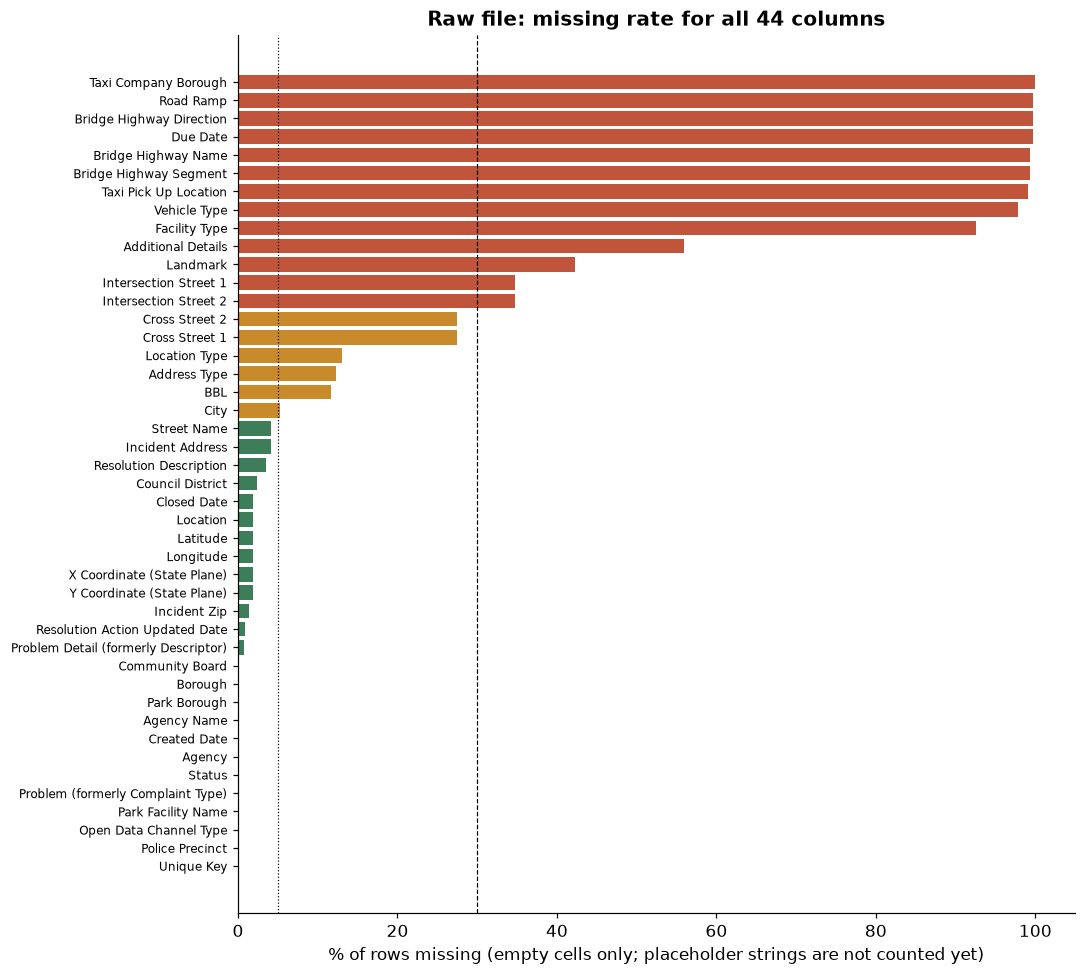

In [34]:
plot_step0(S)

### Step 1 results · Redundant structure
*What to look for:* **A** the column count, **B** how many rows were removed, **C** the two broken agency series (dashed) becoming one continuous series (thick).

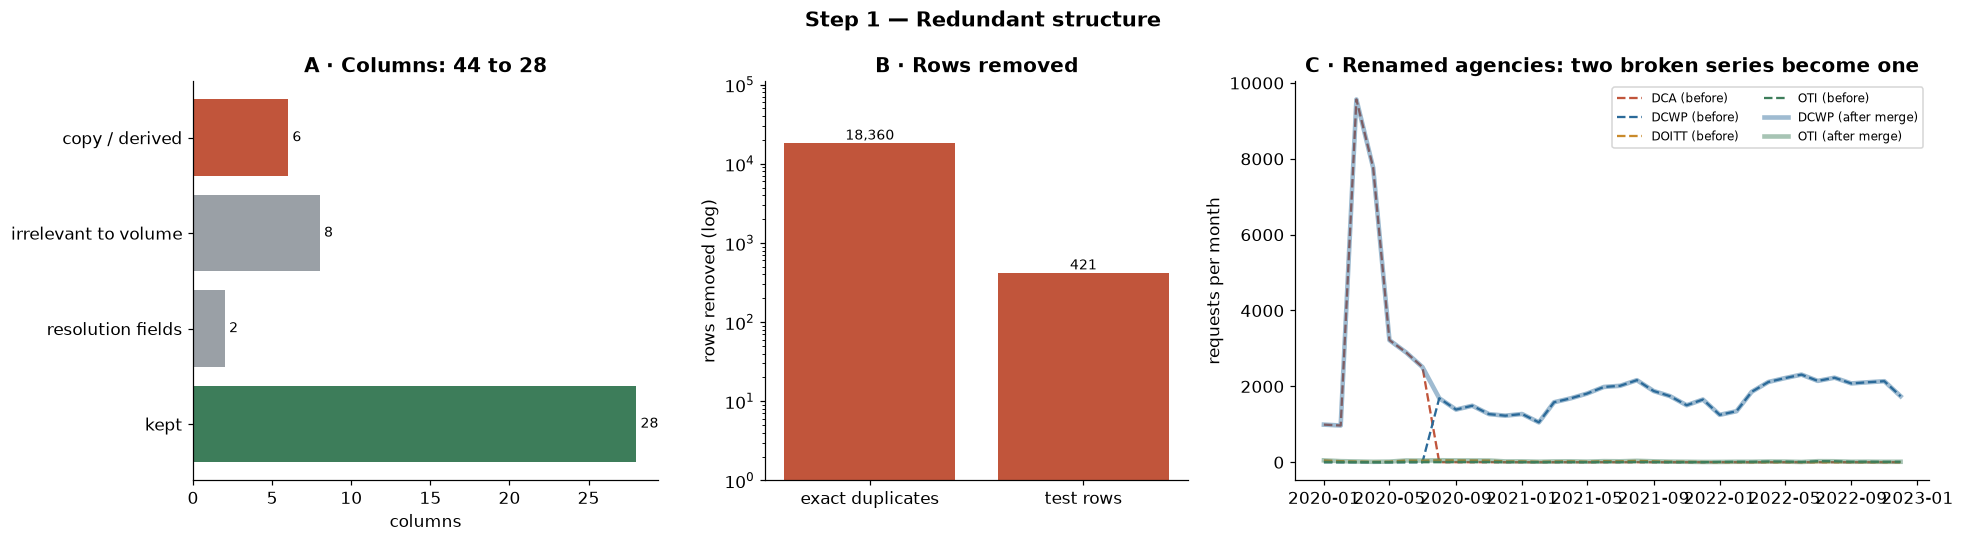

In [35]:
plot_step1(S)

In [36]:
say(
    f"**Takeaway.** Dropped {len(DROP1)} columns ({len(RAW_COLS)} to {len(RAW_COLS) - len(DROP1)}), "
    f"{S['dups']:,} exact duplicate rows and {S['test_dropped']:,} test rows. "
    f"{S['renamed']:,} rows under the old agency codes were merged, so DCWP and OTI are now continuous series."
)

**Takeaway.** Dropped 16 columns (44 to 28), 18,360 exact duplicate rows and 421 test rows. 28,574 rows under the old agency codes were merged, so DCWP and OTI are now continuous series.

### Step 2 results · Numbers and dates stored as text
*What to look for:* **A** every column starts as text, **B** the ZIP column is mostly valid but contains fake values, **C** `describe()` now reports the coordinates.

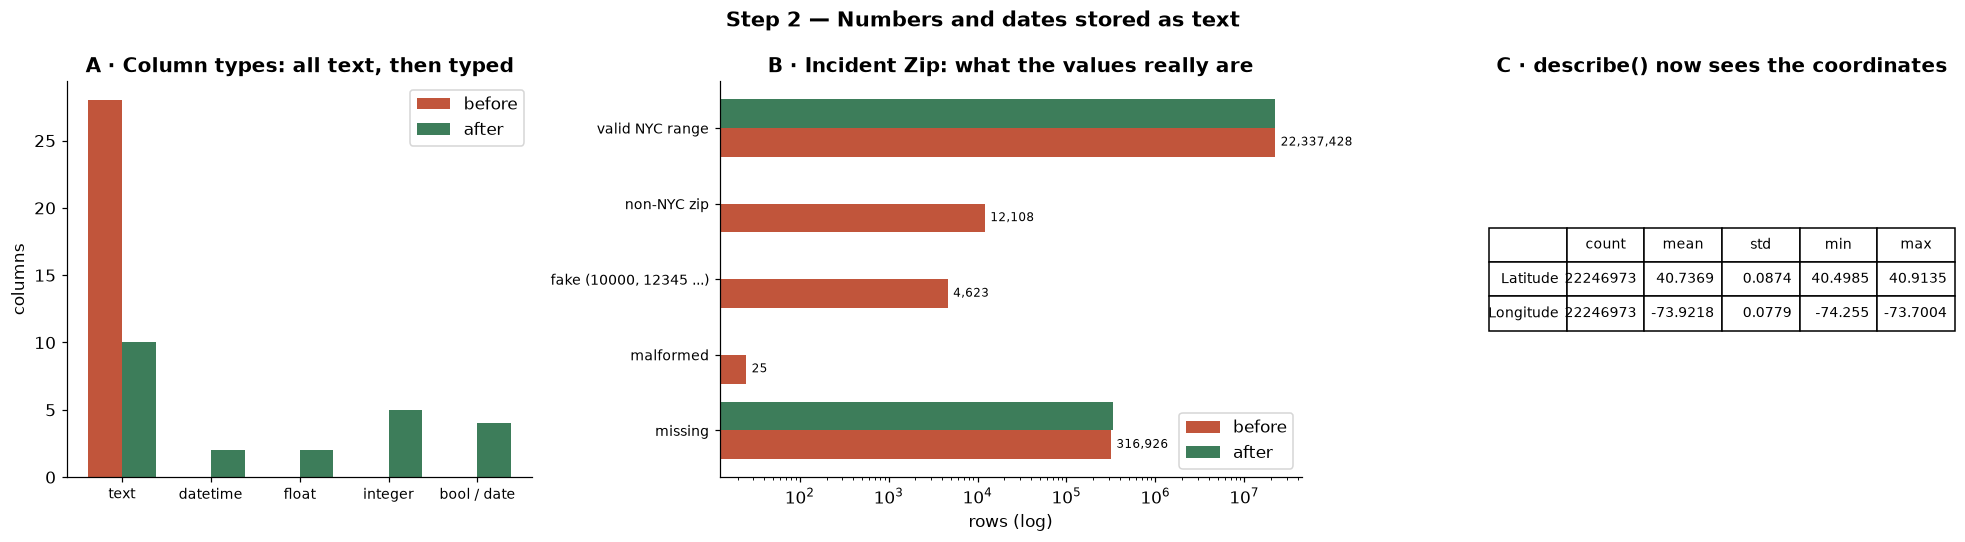

In [37]:
plot_step2(S)

In [38]:
bad_zips = S["zip_before"].get("fake", 0) + S["zip_before"].get("non-NYC", 0) + S["zip_before"].get("malformed", 0)
say(
    f"**Takeaway.** Dates and coordinates are now real types and parsing failed on {S['closed_parse_fail']} rows. "
    f"{bad_zips:,} ZIP values were not valid NYC ZIPs and became missing "
    f"({S['zip_before'].get('fake', 0):,} of them fake, such as 10000 and 12345). "
    f"{S['coords_out']} coordinate outside NYC was set to missing."
)

**Takeaway.** Dates and coordinates are now real types and parsing failed on 0 rows. 16,756 ZIP values were not valid NYC ZIPs and became missing (4,623 of them fake, such as 10000 and 12345). 1 coordinate outside NYC was set to missing.

### Step 3 results · Missing data
*What to look for:* in **A**, the grey bar is what `isna()` reports and the coloured bar is the truth. Where they differ, placeholder strings were hiding. **B/C** show the impossible values.

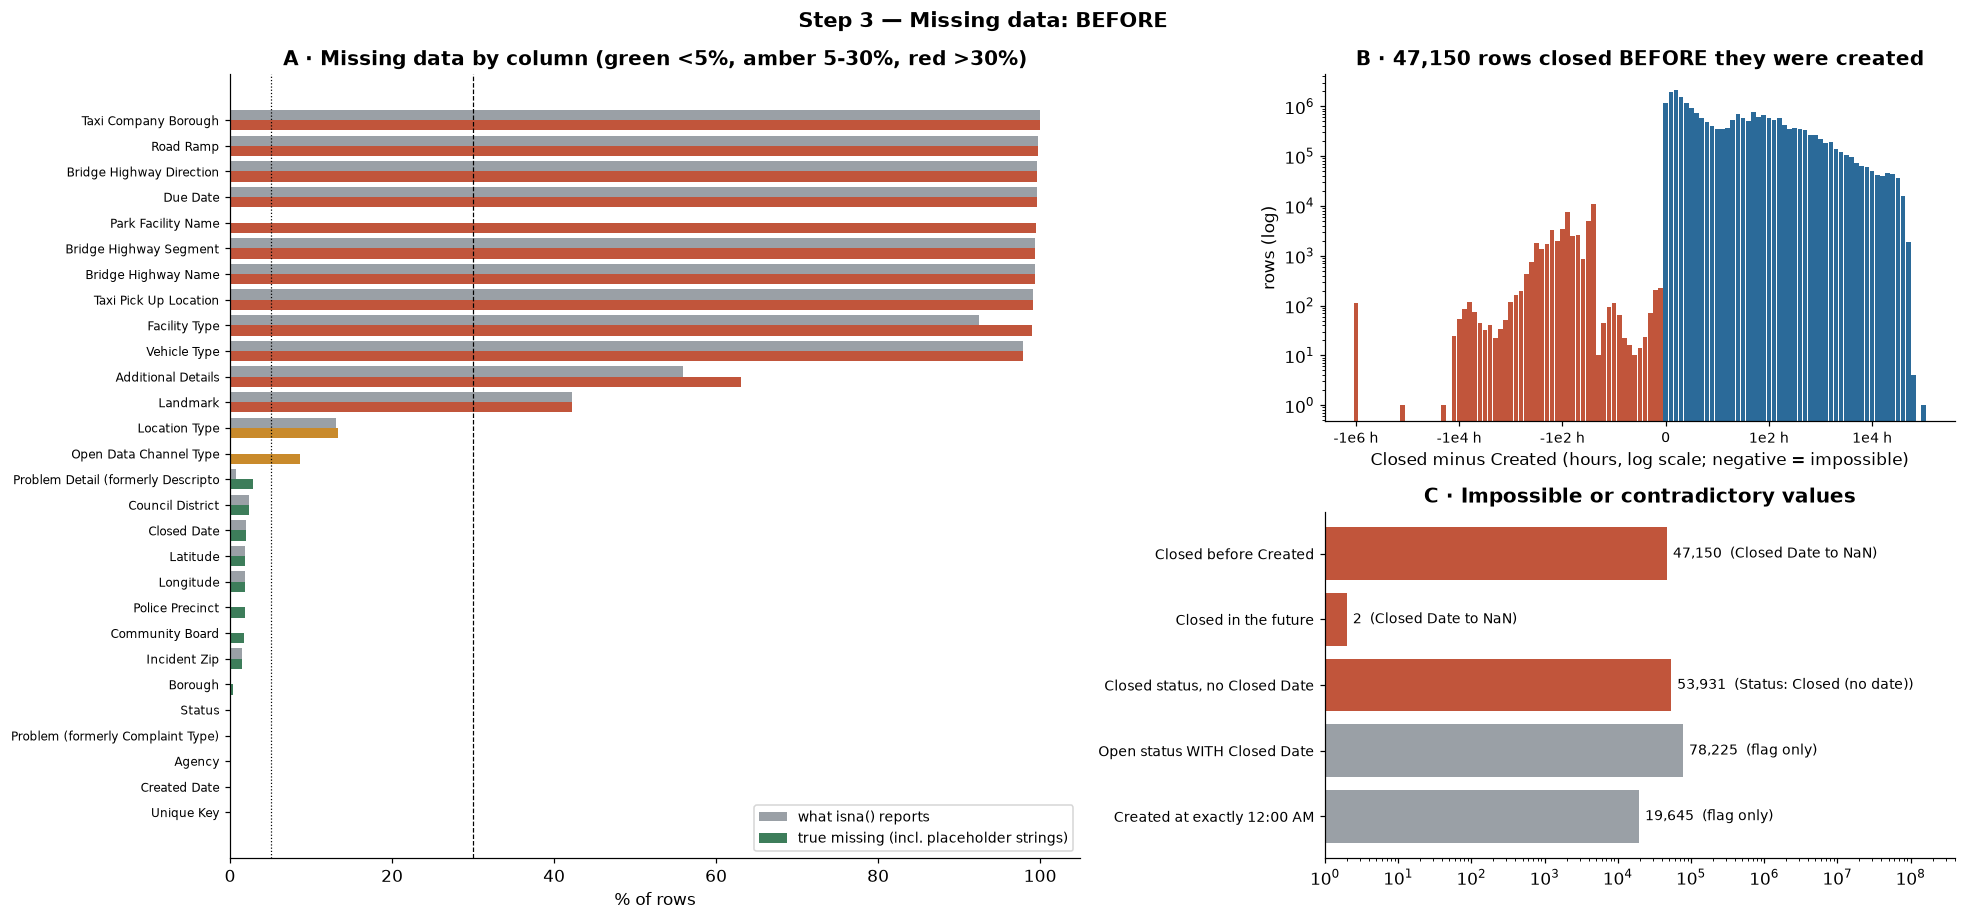

In [39]:
missing_table = plot_step3_before(S)

In [40]:
# Safety check: the columns dropped using the sample must be exactly the >30% columns on the full data.
full_data_drop = set(missing_table.index[missing_table["true_pct"] > 30])
assert full_data_drop == set(DROP_GT30), "the full data disagrees with the rule applied on the sample"
print("Check passed: the sample-based drop list equals the full-data drop list.")

Check passed: the sample-based drop list equals the full-data drop list.


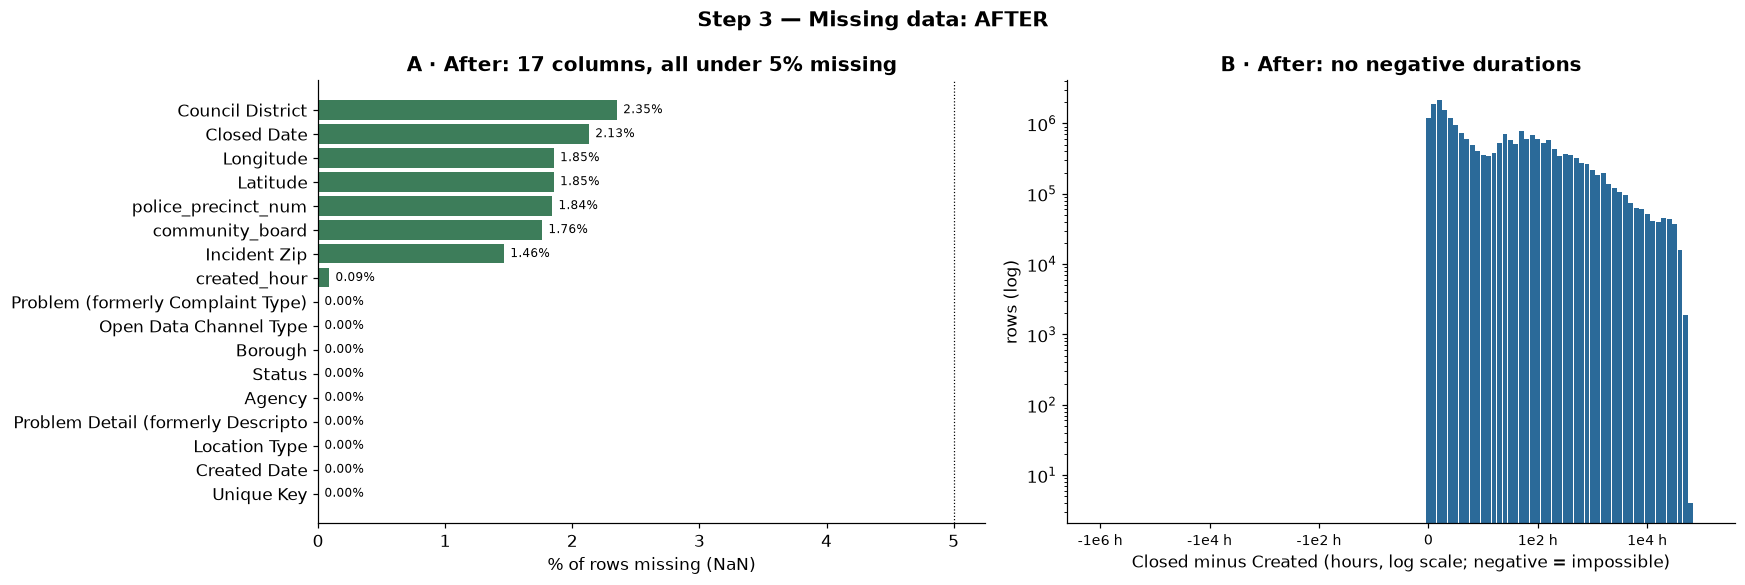

In [41]:
plot_step3_after(S)

In [42]:
final = final_file_counts()
gap = missing_table["true_pct"] - missing_table["isna_pct"]
hidden = missing_table.assign(gap=gap).sort_values("gap", ascending=False).head(3)

hidden_parts = []
for name, row in hidden.iterrows():
    hidden_parts.append(f"{name} ({row.isna_pct:.1f}% to {row.true_pct:.1f}%)")
hidden_text = ", ".join(hidden_parts)

say(
    f"**Takeaway.** `isna()` badly understated missing data in some columns: {hidden_text}. "
    f"{len(DROP_GT30)} columns over 30% missing were dropped. "
    f"In the final file, {final['closed_before_created']:,} impossible close times were set to missing, "
    f"{final['closed_no_date']:,} 'Closed' rows without a close date were relabelled, "
    f"and every remaining column is under 5% missing."
)

**Takeaway.** `isna()` badly understated missing data in some columns: Park Facility Name (0.0% to 99.5%), Open Data Channel Type (0.0% to 8.6%), Additional Details (55.9% to 63.1%). 12 columns over 30% missing were dropped. In the final file, 46,778 impossible close times were set to missing, 53,919 'Closed' rows without a close date were relabelled, and every remaining column is under 5% missing.

### Step 4 results · Packed and indirect fields
*What to look for:* **A** hour 0 is slightly inflated by date-only timestamps (red taller than green), **B** case variants merged, **C** the same rows before and after.

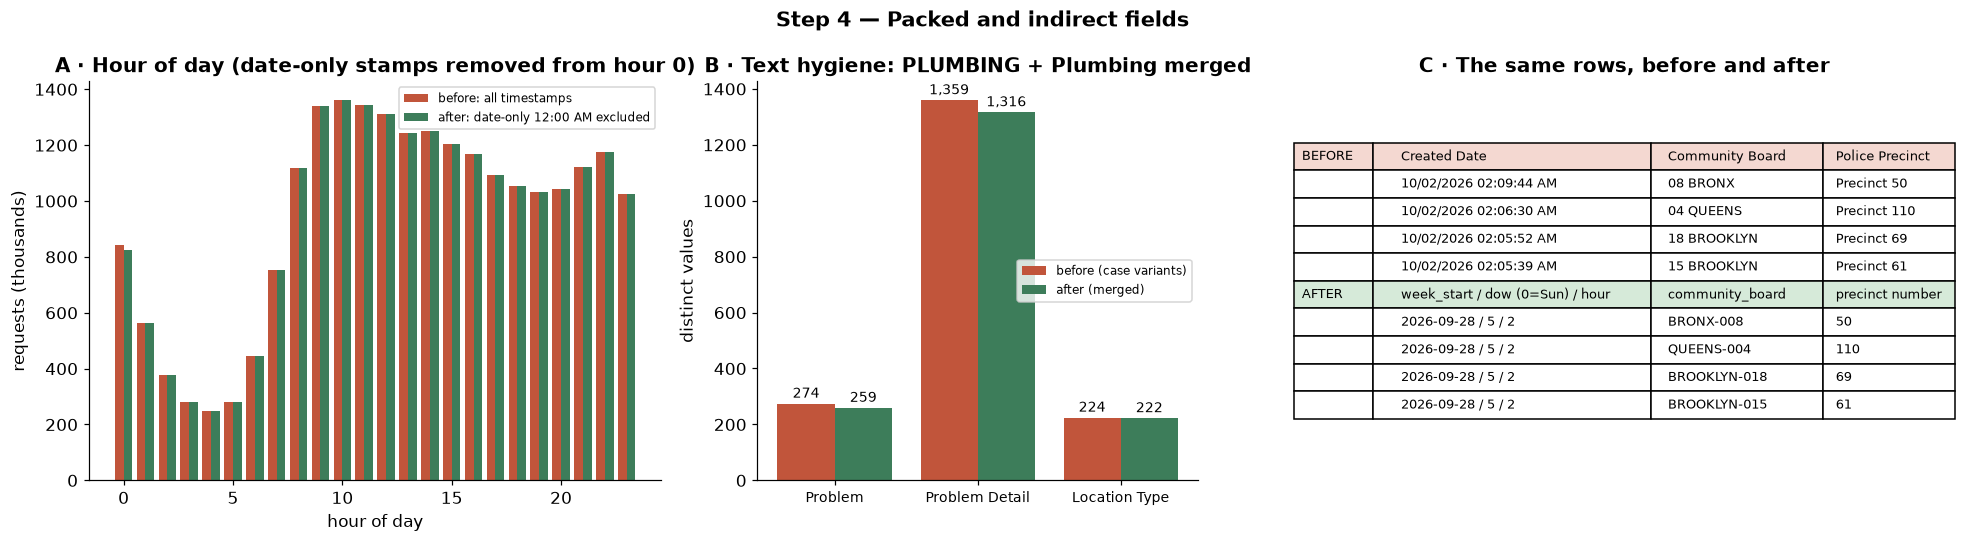

In [43]:
plot_step4(S)

In [44]:
removed = {column: len(S["vals_before"][column]) - len(S["vals_after"][column]) for column in TEXT3}
say(
    f"**Takeaway.** Created Date is now unpacked into week, weekday and hour. "
    f"Community Board is a borough-plus-number id, and Police Precinct is a number. "
    f"Case variants merged: {removed[PROB]} Problem values, {removed[DETAIL]} Problem Detail values, "
    f"{removed['Location Type']} Location Type values."
)

**Takeaway.** Created Date is now unpacked into week, weekday and hour. Community Board is a borough-plus-number id, and Police Precinct is a number. Case variants merged: 15 Problem values, 43 Problem Detail values, 2 Location Type values.

### Sanity check · the target series itself
The cleaned data feeds the weekly forecast, so look at the weekly counts.
The **first and last weeks are partial** (data starts Wednesday 2020-01-01 and ends Friday 2026-10-02 at 02:09), so they must be excluded from modelling.

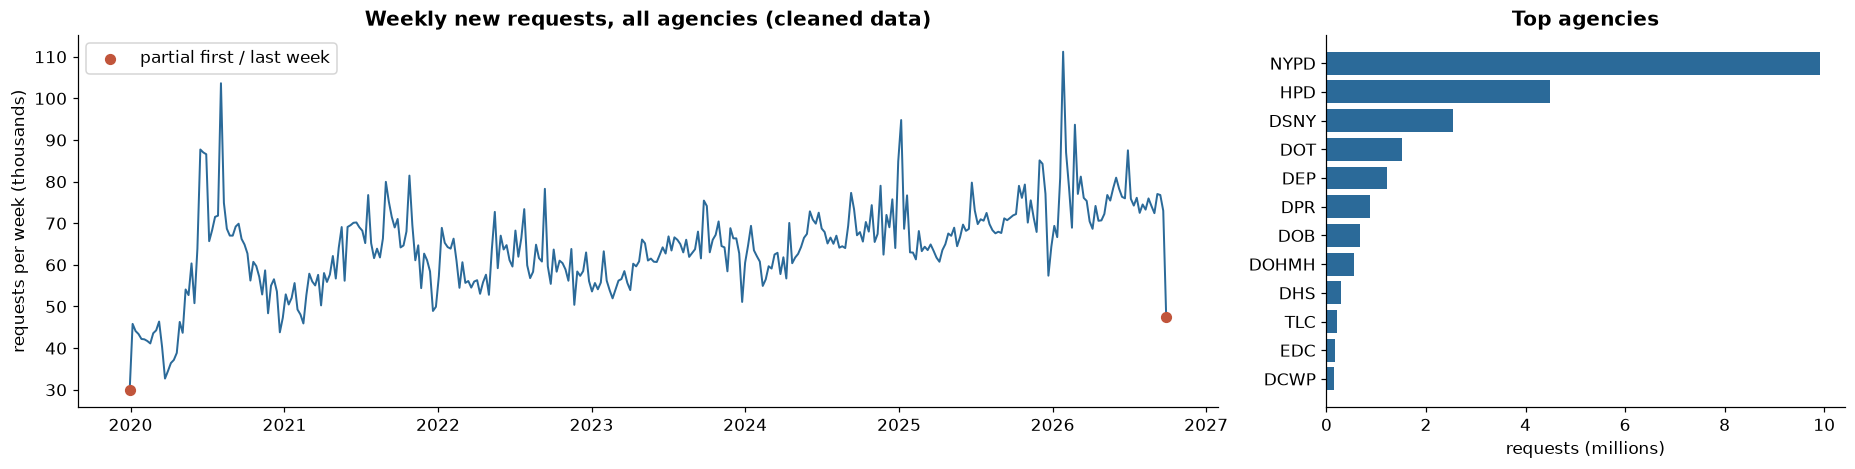

**Takeaway.** First week 2019-12-30: 29,839 requests; last week 2026-09-28: 47,521 requests (partial). A typical full week is about 64,378.

In [45]:
weekly = plot_weekly(S)
say(
    f"**Takeaway.** First week {weekly.index[0].date()}: {weekly.iloc[0]:,} requests; "
    f"last week {weekly.index[-1].date()}: {weekly.iloc[-1]:,} requests (partial). "
    f"A typical full week is about {int(weekly.iloc[1:-1].median()):,}."
)

---
<a id="part5"></a>
## Part 5 · Validation against the DuckDB version
The same cleaning was also done independently with DuckDB (SQL instead of pandas) to produce a reference file.
If two independent implementations agree on every count, neither has a bug.

This check is **optional**: it runs only if the reference file exists (it is not part of this repository, so it is skipped when you run the notebook yourself).
DuckDB is used only here, for checking.

In [46]:
import duckdb

PANDAS_FILES = f"'{OUT}/final-*.parquet'"
REFERENCE_PATH = "_archive/cleaning/cleaned.parquet"
DUCKDB_FILE = f"'{REFERENCE_PATH}'"
con = duckdb.connect()


def scalar(sql):
    return con.execute(sql).fetchone()[0]


def both(sql_template):
    """Run the same query on both datasets; the template uses {T} for the table."""
    pandas_value = scalar(sql_template.format(T=PANDAS_FILES))
    duckdb_value = scalar(sql_template.format(T=DUCKDB_FILE))
    return pandas_value, duckdb_value

In [47]:
if LIMIT or not os.path.exists(REFERENCE_PATH):
    print("Reference file not found (or quick-test run): validation skipped.")
else:
    checks = {}
    checks["row count"] = both("select count(*) from {T}")

    for column in ["Closed Date", "Incident Zip", "Latitude", "Council District", "community_board", "police_precinct_num"]:
        checks[f"missing: {column}"] = both(f'select sum(("{column}" is null)::int) from {{T}}')

    for flag in ["flag_closed_before_created", "flag_open_with_closed_date", "flag_date_only_timestamp"]:
        checks[f"rows flagged: {flag}"] = both(f"select sum({flag}::int) from {{T}}")

    checks["status = 'Closed (no date)'"] = both("select count(*) from {T} where Status = 'Closed (no date)'")
    checks["distinct Problem values"] = both(f'select count(distinct "{PROB}") from {{T}}')
    checks["distinct community boards"] = both("select count(distinct community_board) from {T}")

    weekly_sql = (
        "select count(*) from "
        "(select week_start, Agency, Borough, count(*) n from {A} group by all) a "
        "full join (select week_start, Agency, Borough, count(*) n from {B} group by all) b "
        "using (week_start, Agency, Borough) where a.n is distinct from b.n"
    )
    differing_cells = scalar(weekly_sql.format(A=PANDAS_FILES, B=DUCKDB_FILE))
    checks["week x agency x borough cells that differ"] = (differing_cells, 0)

    result = pd.DataFrame(checks, index=["pandas", "duckdb"]).T
    result["match"] = result["pandas"] == result["duckdb"]

    def colour_match(value):
        return "background-color: #d6ead9" if value else "background-color: #f4d8d1"

    display(result.style.format({"pandas": "{:,.0f}", "duckdb": "{:,.0f}"}).map(colour_match, subset=["match"]))

    if result["match"].all():
        say("**All checks match.** The pandas and DuckDB pipelines agree on every count.")
    else:
        say("**Mismatch found.** Inspect the red rows above.")

,pandas,duckdb,match
row count,"22,652,750","22,652,750",True
missing: Closed Date,"482,687","482,687",True
missing: Incident Zip,"331,360","331,360",True
missing: Latitude,"420,051","420,051",True
missing: Council District,"532,461","532,461",True
missing: community_board,"399,220","399,220",True
missing: police_precinct_num,"417,102","417,102",True
rows flagged: flag_closed_before_created,"46,778","46,778",True
rows flagged: flag_open_with_closed_date,"77,799","77,799",True
rows flagged: flag_date_only_timestamp,"19,615","19,615",True


**All checks match.** The pandas and DuckDB pipelines agree on every count.

---
<a id="part6"></a>
## Part 6 · Final decision table

| Step | Column / issue | Decision | Because |
|---|---|---|---|
| **1 Redundant** | Park Borough, Location, Agency Name, Street Name | drop | exact copies / derived from other columns |
| 1 | X/Y State Plane | drop | same position as Lat/Lon in another projection |
| 1 | Cross/Intersection streets, address, BBL, Address Type, City, Resolution fields | drop | irrelevant to weekly agency × borough volume |
| 1 | Unique Key | keep as ID; exclude from duplicate test | a unique ID hides duplicates |
| 1 | exact duplicates; test rows | drop | identical on all other fields; test-looking records |
| 1 | DCA → DCWP, DOITT → OTI | merge | same department under a new code; keeps series continuous |
| **2 Types** | Created / Closed Date | parse to datetime | stored as text |
| 2 | Latitude / Longitude | float; outside NYC → NaN | stored as text; impossible points |
| 2 | Incident Zip | text label; fake / non-NYC / malformed → NaN | a label, not a quantity; fake ZIPs would be fake hotspots |
| **3 Missing** | placeholder strings | → NaN (exact match) | `isna()` cannot see them |
| 3 | columns over 30% missing | drop | too sparse; mostly structural |
| 3 | 5–30% and low-impact categoricals | fill `"Unknown"` | a mode would invent data |
| 3 | Closed < Created, or in the future | Closed Date → NaN, flag | the request is valid; only the close time is impossible |
| 3 | Closed status without date; open with date; 12:00 AM stamps | relabel; flag; flag | contradictions are surfaced, not silently fixed |
| **4 Packed** | Created Date | week_start, year, weekday, hour | packs date and time |
| 4 | Community Board | `BRONX-007` | the number alone is ambiguous across boroughs |
| 4 | Police Precinct | integer | a label wrapping a number |
| 4 | case variants in text categories | merge to the most frequent spelling | `PLUMBING` vs `Plumbing` would split one category |

### Still to do before modelling
- Exclude the partial first and last weeks.
- Zero-fill weeks only between a series' first and last active week (OSE ended in 2022, OOS began in 2025).
- Require at least 52 weeks of history and at least 5 requests per week for a series to be forecast.
- Test with and without 2020 (COVID level shift).